In [ ]:
# Import the necessary library
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

In [6]:
# Making working directory, it will not create new folder again the folder is already there.

import os
os.makedirs("content/drive/MyDrive/Colab Notebooks/ML_for_Architects/collecting data", exist_ok=True)
os.chdir("content/drive/MyDrive/Colab Notebooks/ML_for_Architects/collecting data")

In [7]:
import os
print(os.getcwd())

c:\Users\Shangde\Downloads\content\drive\MyDrive\Colab Notebooks\ML_for_Architects\collecting data


### Task 1: Data Collection through Request and BeautifulSoup 
Please update the URLs in the list below to your URLs, currently they are the same

In [15]:
list_url = [
    'https://www.archdaily.com/1012067/terzetto-house-conform-architects?ad_content=1012067&ad_medium=widget&ad_name=featured_loop_main',
    'https://www.archdaily.com/1012067/terzetto-house-conform-architects?ad_content=1012067&ad_medium=widget&ad_name=featured_loop_main',
    'https://www.archdaily.com/1012067/terzetto-house-conform-architects?ad_content=1012067&ad_medium=widget&ad_name=featured_loop_main',
]

In [ ]:
import re, json, requests
from bs4 import BeautifulSoup

def paragraphs_from_html(html):
    """Text of each <p> in a piece of HTML, even when tags are badly nested; image captions removed."""
    html = re.sub(r"<figure.*?</figure>", " ", html, flags=re.S)
    texts = []
    for chunk in re.split(r"<p[^>]*>", html)[1:]:
        text = BeautifulSoup(chunk.split("</p>")[0], "html.parser").get_text(" ", strip=True)
        if len(text) > 40 and text not in texts:
            texts.append(text)
    return texts

def url_extraction(x):
    url = list_url[x]
    response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
    if response.status_code != 200:
        print(f"Error: {response.status_code}")
        return
    # BeautifulSoup parses the HTML of the page so we can search it
    soup = BeautifulSoup(response.text, "html.parser")
    article = soup.find("article") or soup
    # 1) paragraphs that are in the page itself (news articles)
    extracted_text = []
    for paragraph in article.find_all("p"):
        text = paragraph.get_text(" ", strip=True)
        if len(text) > 40 and text not in extracted_text:
            extracted_text.append(text)
    # 2) project pages: the text is NOT in the page. The page only has an empty <div id="content-placeholder">
    #    and the browser loads the text afterwards from <post-id>/gated-content.json. We ask for that file too.
    if soup.find(id="content-placeholder") is not None:
        post_id = re.search(r"archdaily\.com/(\d+)", url).group(1)
        extra = requests.get(f"https://www.archdaily.com/{post_id}/gated-content.json")
        if extra.status_code == 200 and "json" in extra.headers.get("content-type", ""):
            extracted_text += [t for t in paragraphs_from_html(extra.json()["content"]) if t not in extracted_text]
    # show the result and save it as text and as JSON
    with open(f"extracted_text_{x}.txt", "w", encoding="utf-8") as file:
        file.write("\n".join(extracted_text) + "\n")
    with open(f"extracted_text_{x}.json", "w", encoding="utf-8") as file:
        json.dump(extracted_text, file, ensure_ascii=False, indent=2)

for x in range(len(list_url)):
    url_extraction(x)

Now we merge all jsons into on json, and merge all txt in to one

In [18]:
json_name = "all_extracted_text.json"
txt_name = "all_extracted_text.txt"

import glob, json, re

# Find all the JSON and TXT files in the working folder (the merged files themselves are left out,
# so the cell can be run again). They are sorted by the number in the file name: _0, _1, _2, ...
def number_in(name):
    match = re.search(r"(\d+)", name)
    return int(match.group(1)) if match else -1

json_files = sorted([f for f in glob.glob("extracted_text_*.json") if not f.startswith("all_")], key=number_in)
txt_files = sorted([f for f in glob.glob("extracted_text_*.txt") if not f.startswith("all_")], key=number_in)
print("JSON files found:", json_files)
print("TXT files found: ", txt_files)

# Merge the JSON files into one dictionary: file name -> its list of paragraphs
merged = {}
for path in json_files:
    with open(path, encoding="utf-8") as file:
        merged[path] = json.load(file)
with open(json_name, "w", encoding="utf-8") as file:
    json.dump(merged, file, ensure_ascii=False, indent=2)

# Merge the TXT files into one text file, with a header line before the content of each file
with open(txt_name, "w", encoding="utf-8") as out:
    for path in txt_files:
        with open(path, encoding="utf-8") as file:
            out.write(f"===== {path} =====\n{file.read().strip()}\n\n")

print(f"Merged {len(json_files)} JSON files -> all_extracted_text.json ({sum(len(v) for v in merged.values())} paragraphs)")
print(f"Merged {len(txt_files)} TXT files  -> all_extracted_text.txt")

JSON files found: ['extracted_text_0.json', 'extracted_text_1.json', 'extracted_text_2.json']
TXT files found:  ['extracted_text_0.txt', 'extracted_text_1.txt', 'extracted_text_2.txt']
Merged 3 JSON files -> all_extracted_text.json (21 paragraphs)
Merged 3 TXT files  -> all_extracted_text.txt


### Task 2: Data Collection through Scrapy - text
Please update the URLs in the list below to your URLs, currently they are the same

In [19]:
list_url = [
    'https://www.archdaily.com/1012067/terzetto-house-conform-architects?ad_content=1012067&ad_medium=widget&ad_name=featured_loop_main',
    'https://www.archdaily.com/1012067/terzetto-house-conform-architects?ad_content=1012067&ad_medium=widget&ad_name=featured_loop_main',
    'https://www.archdaily.com/1012067/terzetto-house-conform-architects?ad_content=1012067&ad_medium=widget&ad_name=featured_loop_main',
]

In [20]:
pip install scrapy

In [21]:
# A Scrapy spider runs as a separate program, so it cannot see the variables of this notebook.
# We save the URL list to a small file that the spider reads when it starts.
import json
with open("urls.json", "w", encoding="utf-8") as file:
    json.dump(list_url, file)
print(f"{len(list_url)} URLs saved to urls.json")

3 URLs saved to urls.json


In [22]:
%%writefile my_spider.py
# The line above writes this cell to the file my_spider.py instead of running it.
import json, re
import scrapy


class MySpider(scrapy.Spider):
    # The spider is given a name, which is used to identify it when running.
    name = "my_spider_text"

    # The URL(s) from which the spider starts. They were saved to urls.json by the previous cell.
    start_urls = json.load(open("urls.json", encoding="utf-8"))

    # parse() is called with the web page's response. Data is extracted from the HTML with CSS selectors.
    def parse(self, response):
        # 'title::text' targets the text content of the <title> tag
        title = response.css("title::text").get()

        # every <p> inside the article; string(.) gives the full text of a paragraph, even with <em> or <a> inside
        paragraphs = [p.xpath("string(.)").get().strip() for p in response.css("article p")]
        paragraphs = [t for t in paragraphs if len(t) > 40]

        data = {"url": response.url, "title": title, "content": paragraphs}

        # ArchDaily project pages do not put the article text in the page: the browser loads it later from
        # <post-id>/gated-content.json. If the page has that placeholder, we request the JSON file as well
        # and let parse_gated() add its paragraphs. Otherwise the data is complete and we return it now.
        if response.css("#content-placeholder"):
            post_id = re.search(r"archdaily\.com/(\d+)", response.url).group(1)
            yield scrapy.Request(f"https://www.archdaily.com/{post_id}/gated-content.json",
                                 callback=self.parse_gated, cb_kwargs={"data": data}, dont_filter=True,
                                 meta={"handle_httpstatus_all": True})
        else:
            yield data

    def parse_gated(self, response, data):
        if response.status == 200:            # some pages answer 400 here: then we keep what the page gave us
            html = json.loads(response.text)["content"]
            for p in scrapy.Selector(text=html).css("p"):
                text = p.xpath("string(.)").get().strip()
                if len(text) > 40 and text not in data["content"]:
                    data["content"].append(text)
        yield data

Overwriting my_spider.py


In [ ]:
import json, sys

# Run the spider as a separate program (Scrapy cannot be restarted inside a notebook).
# -O writes all results to scrapy_output.json (overwriting it); --loglevel=WARNING hides the routine log lines.
!"{sys.executable}" -m scrapy runspider my_spider.py -O all_scrapy_output.json --loglevel=WARNING

with open("all_scrapy_output.json", encoding="utf-8") as file:
    results = json.load(file)

for item in results:
    print(item["title"])
    print("  ", item["url"])
    for paragraph in item["content"]:
        print("   -", paragraph[:100])
    print()
print(f"{len(results)} pages scraped -> all_scrapy_output.json")

Terzetto House / ConForm Architects | ArchDaily
   https://www.archdaily.com/1012067/terzetto-house-conform-architects?ad_content=1012067&ad_medium=widget&ad_name=featured_loop_main
   - Text description provided by the architects. The existing garden flat was compromised in its arrange
   - The original concept of the rear extension draws on a reinterpretation of the decorative bay windows
   - The concept is enhanced further in section, by drawing on the tri-sectional elements of a typical ba
   - The client wished to reorientate the property with living spaces towards the garden, whilst also see
   - The kitchen comprises sophisticated light oak cabinetry, creating ample room for storage and functio
   - Within the rear living space, ConForm has demonstrated its expertise in precision detailing with the
   - A nod to the amphitheatrical is experienced here; the concrete plinth and bench make the living spac

Terzetto House / ConForm Architects | ArchDaily
   https://www.archdaily.co

### Task 3: Data Collection through Scrapy - Images
This task uses the same `list_url` as Task 1 and 2 (update that list above if you want other pages)

In [24]:
list_url = [
    'https://www.archdaily.com/1012067/terzetto-house-conform-architects?ad_content=1012067&ad_medium=widget&ad_name=featured_loop_main',
    'https://www.archdaily.com/1012067/terzetto-house-conform-architects?ad_content=1012067&ad_medium=widget&ad_name=featured_loop_main',
    'https://www.archdaily.com/1012067/terzetto-house-conform-architects?ad_content=1012067&ad_medium=widget&ad_name=featured_loop_main',
]

In [25]:
%%writefile my_image_spider.py
# The line above writes this cell to the file my_image_spider.py instead of running it.
import json, re
import scrapy


class ArchDailyImagesSpider(scrapy.Spider):
    # Define the name of the spider
    name = "my_spider_img"

    # The starting URL(s): the list_url of this notebook, saved to urls.json by the next cell
    start_urls = json.load(open("urls.json", encoding="utf-8"))

    # Scrapy's ImagesPipeline downloads every URL found in the "image_urls" field of an item
    # and saves the files in the IMAGES_STORE folder. Images smaller than 300 px (icons, thumbnails) are skipped.
    custom_settings = {
        "ITEM_PIPELINES": {"scrapy.pipelines.images.ImagesPipeline": 1},
        "IMAGES_STORE": "images",
        "IMAGES_MIN_WIDTH": 300,
        "IMAGES_MIN_HEIGHT": 300,
        "USER_AGENT": "Mozilla/5.0",
    }

    def photo_urls(self, selector):
        """Addresses of the photos in a piece of HTML. ArchDaily loads most photos lazily: the real address is then
        in the "data-src" attribute and "src" only holds a tiny placeholder. Only photos hosted on images.adsttc.com
        are kept (no icons), without the small "thumb_jpg" thumbnails."""
        urls = selector.css("img::attr(data-src), img::attr(src)").getall()
        return [u for u in urls if "images.adsttc.com" in u and "/thumb_jpg/" not in u]

    # The parse method is called with the web page's response as an argument.
    def parse(self, response):
        # One item per page. The pipeline downloads the URLs in "image_urls" and adds an "images" field with the saved paths.
        data = {
            "page": response.url,
            "title": response.css("title::text").get(),
            "image_urls": self.photo_urls(response.css("article")),
        }

        # ArchDaily project pages keep most of the gallery out of the page: the browser loads it later from
        # <post-id>/gated-content.json (the same file that holds the text). If the page has that placeholder,
        # we request the JSON file as well and let parse_gated() add its photos. Otherwise the item is complete.
        if response.css("#content-placeholder"):
            post_id = re.search(r"archdaily\.com/(\d+)", response.url).group(1)
            yield scrapy.Request(f"https://www.archdaily.com/{post_id}/gated-content.json",
                                 callback=self.parse_gated, cb_kwargs={"data": data}, dont_filter=True,
                                 meta={"handle_httpstatus_all": True})
        else:
            yield data

    def parse_gated(self, response, data):
        if response.status == 200:            # some pages answer 400 here: then we keep what the page gave us
            html = json.loads(response.text)["content"]
            data["image_urls"] += self.photo_urls(scrapy.Selector(text=html))
            data["image_urls"] = list(dict.fromkeys(data["image_urls"]))     # each photo once
        yield data

Overwriting my_image_spider.py


Terzetto House / ConForm Architects | ArchDaily
   3 image URLs found, 3 images downloaded
Terzetto House / ConForm Architects | ArchDaily
   3 image URLs found, 3 images downloaded
Terzetto House / ConForm Architects | ArchDaily
   3 image URLs found, 3 images downloaded

21 files in images/full


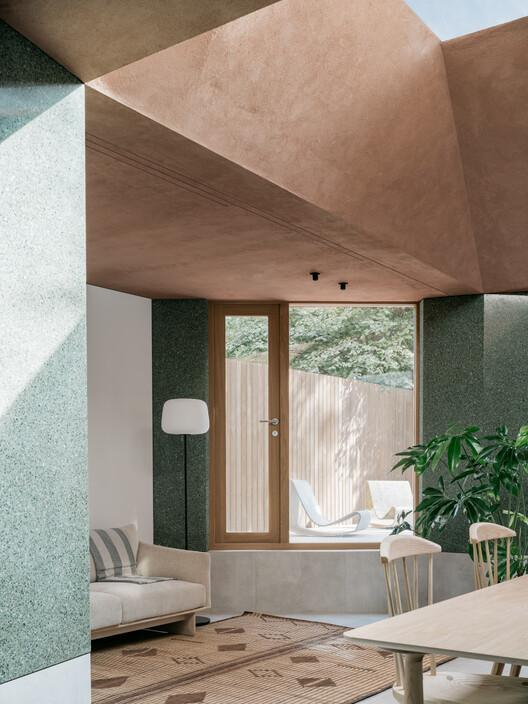

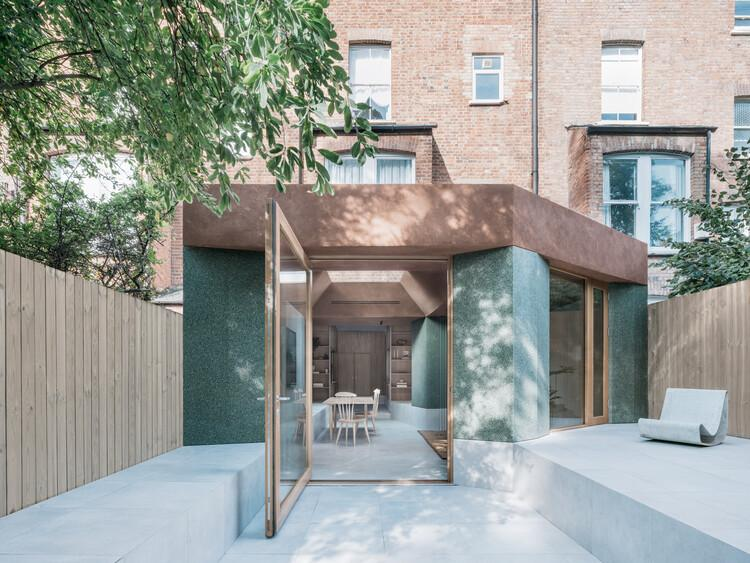

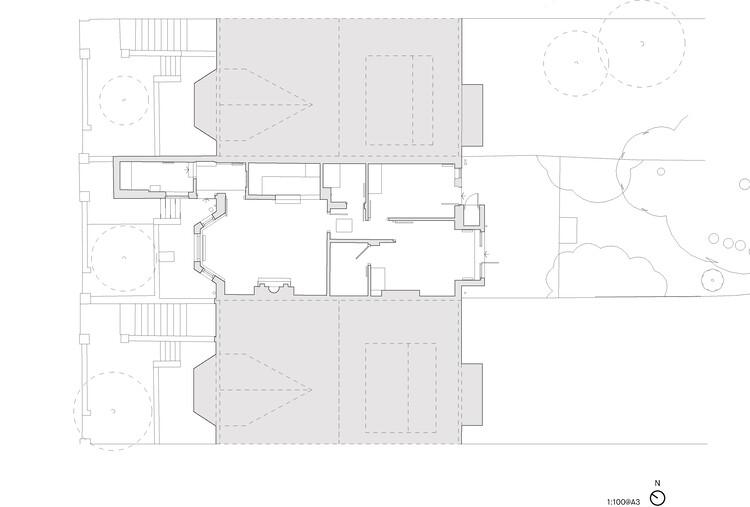

In [27]:
import json, os, sys
from IPython.display import Image, display

# Save the current list_url to urls.json, so the spider (a separate program) uses the same URLs as Task 1 and 2
with open("urls.json", "w", encoding="utf-8") as file:
    json.dump(list_url, file)

# Run the spider as a separate program. The images are saved in the folder images/full/,
# and images_output.json lists, for every page, the image URLs and the saved file paths (--loglevel=ERROR hides the log).
!"{sys.executable}" -m scrapy runspider my_image_spider.py -O all_scrapyimages_output.json --loglevel=ERROR

with open("all_scrapyimages_output.json", encoding="utf-8") as file:
    results = json.load(file)

for item in results:
    print(item["title"])
    print(f"   {len(item['image_urls'])} image URLs found, {len(item['images'])} images downloaded")

# Show the first three downloaded images
files = sorted(os.listdir("images/full"))
print(f"\n{len(files)} files in images/full")
for name in files[:3]:
    display(Image(filename=os.path.join("images/full", name), width=400))